# **Credit Card Fraud Detection**

With the rapid growth of digital transactions, detecting fraudulent activities has become a critical challenge for financial institutions and online merchants. The objective of this project is to analyze transaction-level data containing details such as transaction date, amount, merchant ID, transaction type, and location to develop a machine learning model that can accurately classify whether a transaction is fraudulent or legitimate.

Using historical transaction patterns, the goal is to identify suspicious behaviors and build a reliable classification system that can detect fraud while minimizing false alarms. An effective fraud detection model will help organizations reduce financial losses, enhance customer trust, and strengthen the overall security of digital payment systems through timely and accurate fraud identification.

## **load and inspect the dataset**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Dataset/credit_card_fraud_dataset.csv")
df

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0
...,...,...,...,...,...,...,...
99995,99996,2024-06-07 00:57:36.027591,1057.29,289,refund,San Antonio,0
99996,99997,2023-10-22 23:12:36.027594,297.25,745,refund,San Antonio,0
99997,99998,2024-05-31 19:27:36.027597,3448.56,690,purchase,San Antonio,0
99998,99999,2024-10-18 09:43:36.027601,3750.79,644,purchase,Philadelphia,0


In [ ]:
df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


In [ ]:
df.tail()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
99995,99996,2024-06-07 00:57:36.027591,1057.29,289,refund,San Antonio,0
99996,99997,2023-10-22 23:12:36.027594,297.25,745,refund,San Antonio,0
99997,99998,2024-05-31 19:27:36.027597,3448.56,690,purchase,San Antonio,0
99998,99999,2024-10-18 09:43:36.027601,3750.79,644,purchase,Philadelphia,0
99999,100000,2024-03-05 19:41:36.027606,1596.79,675,refund,Houston,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  object 
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  object 
 5   Location         100000 non-null  object 
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.3+ MB


## **cleaning**

In [ ]:
df.isnull().sum()

,0
TransactionID,0
TransactionDate,0
Amount,0
MerchantID,0
TransactionType,0
Location,0
IsFraud,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(100000, 7)

## **visualization**

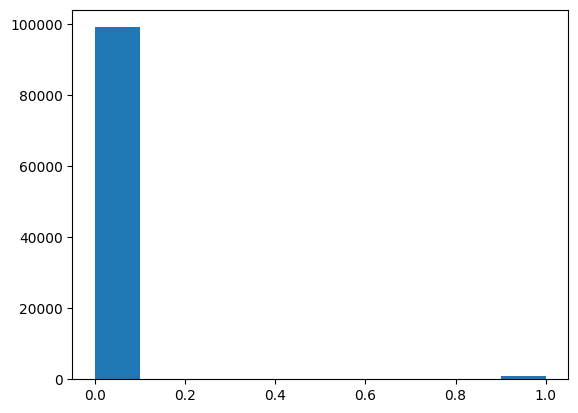

In [ ]:
plt.hist(df["IsFraud"])
plt.show()

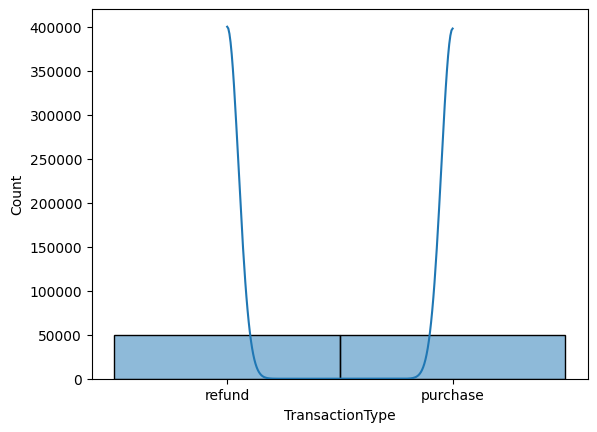

In [ ]:
sns.histplot(df["TransactionType"], kde=True)
plt.show()

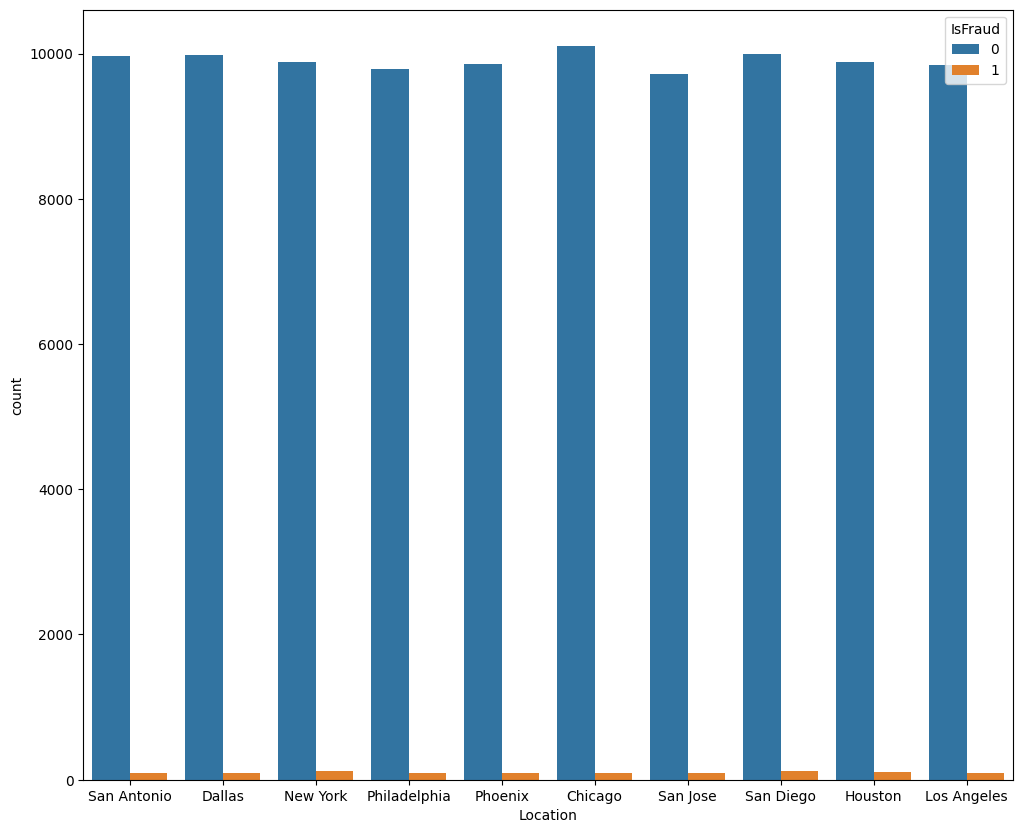

In [ ]:
plt.figure(figsize=(12,10))

sns.countplot(data=df, x="Location", hue="IsFraud")
plt.show()

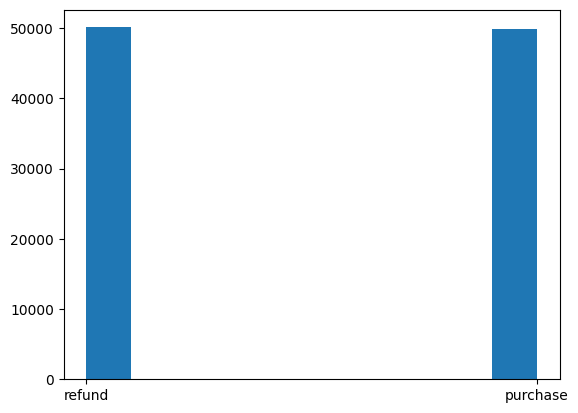

In [ ]:
plt.hist(df["TransactionType"])
plt.show()

<Axes: xlabel='TransactionType', ylabel='Amount'>

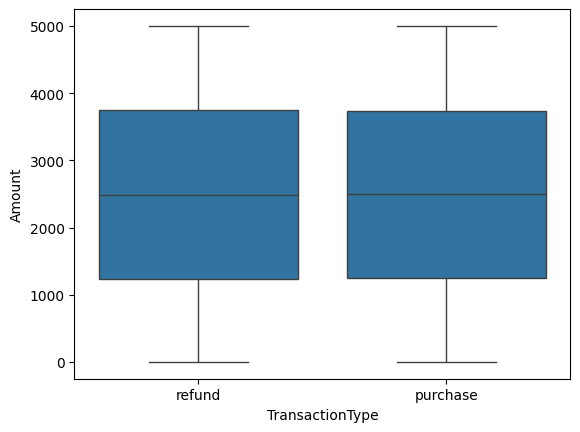

In [ ]:
sns.boxplot(x="TransactionType", y="Amount", data=df)

## **correlation**

In [ ]:
df

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0
...,...,...,...,...,...,...,...
99995,99996,2024-06-07 00:57:36.027591,1057.29,289,refund,San Antonio,0
99996,99997,2023-10-22 23:12:36.027594,297.25,745,refund,San Antonio,0
99997,99998,2024-05-31 19:27:36.027597,3448.56,690,purchase,San Antonio,0
99998,99999,2024-10-18 09:43:36.027601,3750.79,644,purchase,Philadelphia,0


In [ ]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
df["year"] = df["TransactionDate"].dt.year
df["month"] = df["TransactionDate"].dt.month
df["day"] = df["TransactionDate"].dt.day
df["hour"] = df["TransactionDate"].dt.hour
df["minute"] = df["TransactionDate"].dt.minute
df["second"] = df["TransactionDate"].dt.second
df["day_of_week"] = df["TransactionDate"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

In [ ]:
df

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud,year,month,day,hour,minute,second,day_of_week,is_weekend
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0,2024,4,3,14,15,35,2,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0,2024,3,19,13,20,35,1,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0,2024,1,8,10,8,35,0,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0,2024,4,13,23,50,35,5,1
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0,2024,7,12,18,51,35,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,2024-06-07 00:57:36.027591,1057.29,289,refund,San Antonio,0,2024,6,7,0,57,36,4,0
99996,99997,2023-10-22 23:12:36.027594,297.25,745,refund,San Antonio,0,2023,10,22,23,12,36,6,1
99997,99998,2024-05-31 19:27:36.027597,3448.56,690,purchase,San Antonio,0,2024,5,31,19,27,36,4,0
99998,99999,2024-10-18 09:43:36.027601,3750.79,644,purchase,Philadelphia,0,2024,10,18,9,43,36,4,0


In [ ]:
df.drop(["TransactionDate"], inplace=True, axis=1)

In [ ]:
df

,TransactionID,Amount,MerchantID,TransactionType,Location,IsFraud,year,month,day,hour,minute,second,day_of_week,is_weekend
0,1,4189.27,688,refund,San Antonio,0,2024,4,3,14,15,35,2,0
1,2,2659.71,109,refund,Dallas,0,2024,3,19,13,20,35,1,0
2,3,784.00,394,purchase,New York,0,2024,1,8,10,8,35,0,0
3,4,3514.40,944,purchase,Philadelphia,0,2024,4,13,23,50,35,5,1
4,5,369.07,475,purchase,Phoenix,0,2024,7,12,18,51,35,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,1057.29,289,refund,San Antonio,0,2024,6,7,0,57,36,4,0
99996,99997,297.25,745,refund,San Antonio,0,2023,10,22,23,12,36,6,1
99997,99998,3448.56,690,purchase,San Antonio,0,2024,5,31,19,27,36,4,0
99998,99999,3750.79,644,purchase,Philadelphia,0,2024,10,18,9,43,36,4,0


## **correlation**

In [ ]:
df.head()

,TransactionID,Amount,MerchantID,TransactionType,Location,IsFraud,year,month,day,hour,minute,second,day_of_week,is_weekend
0,1,4189.27,688,refund,San Antonio,0,2024,4,3,14,15,35,2,0
1,2,2659.71,109,refund,Dallas,0,2024,3,19,13,20,35,1,0
2,3,784.00,394,purchase,New York,0,2024,1,8,10,8,35,0,0
3,4,3514.40,944,purchase,Philadelphia,0,2024,4,13,23,50,35,5,1
4,5,369.07,475,purchase,Phoenix,0,2024,7,12,18,51,35,4,0


In [ ]:
print(df["TransactionType"].unique())

['refund' 'purchase']


In [ ]:
print(df["Location"].unique())

['San Antonio' 'Dallas' 'New York' 'Philadelphia' 'Phoenix' 'Chicago'
 'San Jose' 'San Diego' 'Houston' 'Los Angeles']


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['TransactionType'] = le.fit_transform(df['TransactionType'])
df['Location'] = le.fit_transform(df['Location'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   Amount           100000 non-null  float64
 2   MerchantID       100000 non-null  int64  
 3   TransactionType  100000 non-null  int64  
 4   Location         100000 non-null  int64  
 5   IsFraud          100000 non-null  int64  
 6   year             100000 non-null  int32  
 7   month            100000 non-null  int32  
 8   day              100000 non-null  int32  
 9   hour             100000 non-null  int32  
 10  minute           100000 non-null  int32  
 11  second           100000 non-null  int32  
 12  day_of_week      100000 non-null  int32  
 13  is_weekend       100000 non-null  int64  
dtypes: float64(1), int32(7), int64(6)
memory usage: 8.0 MB


In [ ]:
df

,TransactionID,Amount,MerchantID,TransactionType,Location,IsFraud,year,month,day,hour,minute,second,day_of_week,is_weekend
0,1,4189.27,688,1,7,0,2024,4,3,14,15,35,2,0
1,2,2659.71,109,1,1,0,2024,3,19,13,20,35,1,0
2,3,784.00,394,0,4,0,2024,1,8,10,8,35,0,0
3,4,3514.40,944,0,5,0,2024,4,13,23,50,35,5,1
4,5,369.07,475,0,6,0,2024,7,12,18,51,35,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,1057.29,289,1,7,0,2024,6,7,0,57,36,4,0
99996,99997,297.25,745,1,7,0,2023,10,22,23,12,36,6,1
99997,99998,3448.56,690,0,7,0,2024,5,31,19,27,36,4,0
99998,99999,3750.79,644,0,5,0,2024,10,18,9,43,36,4,0


### **oversampling SMOTE**

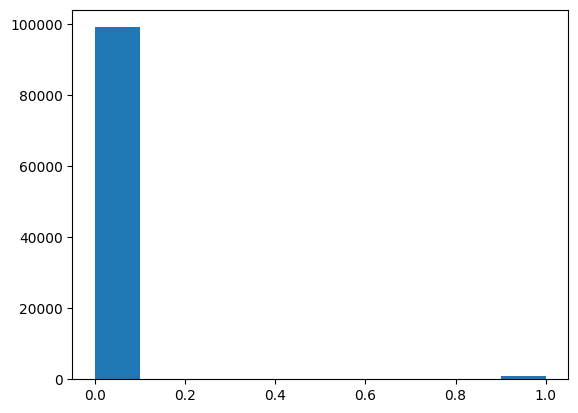

In [ ]:
plt.hist(df["IsFraud"])
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

x = df.drop("IsFraud", axis=1)
y = df["IsFraud"]

smote = SMOTE(random_state=42)

x_resampled, y_resampled = smote.fit_resample(x,y)

In [ ]:
import pandas as pd

df_balanced = pd.concat([pd.DataFrame(x_resampled, columns=x.columns), pd.Series(y_resampled, name="IsFraud")], axis=1)

df_balanced.head()

,TransactionID,Amount,MerchantID,TransactionType,Location,year,month,day,hour,minute,second,day_of_week,is_weekend,IsFraud
0,1,4189.27,688,1,7,2024,4,3,14,15,35,2,0,0
1,2,2659.71,109,1,1,2024,3,19,13,20,35,1,0,0
2,3,784.00,394,0,4,2024,1,8,10,8,35,0,0,0
3,4,3514.40,944,0,5,2024,4,13,23,50,35,5,1,0
4,5,369.07,475,0,6,2024,7,12,18,51,35,4,0,0


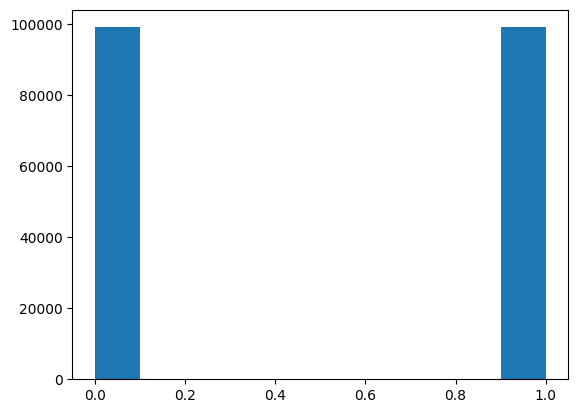

In [ ]:
plt.hist(df_balanced["IsFraud"])
plt.show()

In [ ]:
df = df_balanced

In [ ]:
df["merchant_fraud_rate"] = df.groupby("MerchantID")["IsFraud"].transform("mean")

In [ ]:
df["location_fraud_rate"] = df.groupby("Location")["IsFraud"].transform("mean")

In [ ]:
df["amount_zscore"] = (df["Amount"] - df["Amount"].mean()) / df["Amount"].std()

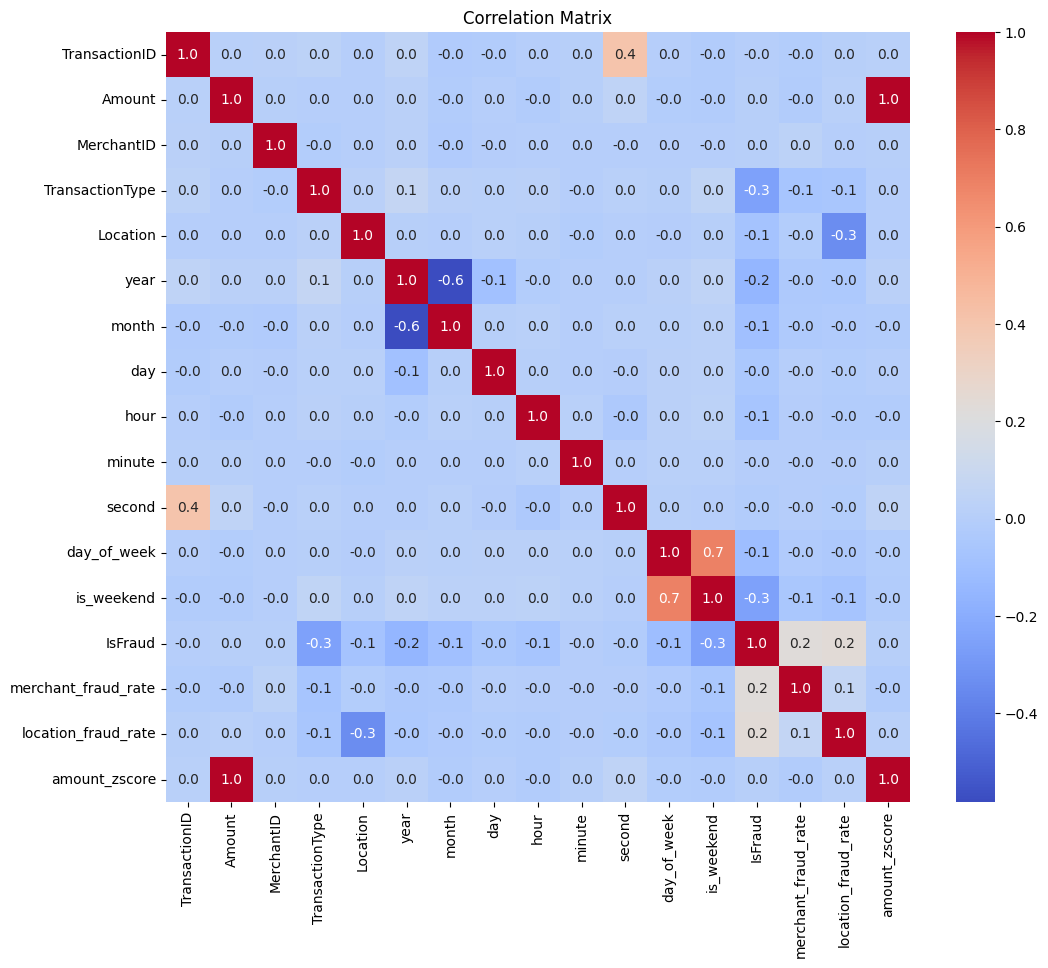

In [ ]:
plt.figure(figsize=(12,10))

corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='0.01f', cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [ ]:
df.drop(['amount_zscore'], inplace=True, axis=1)

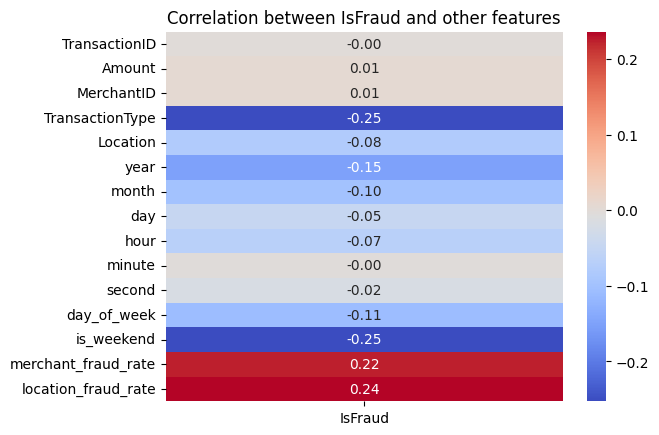

In [ ]:
IsFraud_corr = df.corr()['IsFraud']
IsFraud_corr = IsFraud_corr.drop('IsFraud')

sns.heatmap(IsFraud_corr.to_frame(), annot=True, fmt='0.2f', cmap='coolwarm', cbar=True, annot_kws={'size':10})

plt.title("Correlation between IsFraud and other features")
plt.show()

In [ ]:
df.drop(['TransactionID', 'Amount', 'MerchantID', 'Location', 'day', 'hour', 'minute', 'second'], axis=1, inplace=True)

In [ ]:
df

,TransactionType,year,month,day_of_week,is_weekend,IsFraud,merchant_fraud_rate,location_fraud_rate
0,1,2024,4,2,0,0,0.525862,0.529159
1,1,2024,3,1,0,0,0.418367,0.505232
2,0,2024,1,0,0,0,0.625000,0.580559
3,0,2024,4,5,1,0,0.288000,0.572160
4,0,2024,7,4,0,0,0.565421,0.544842
...,...,...,...,...,...,...,...,...
197995,0,2024,3,1,0,1,0.407609,0.580559
197996,0,2023,7,2,0,1,0.579439,0.572160
197997,1,2023,9,2,0,1,0.595041,0.547551
197998,0,2024,1,1,0,1,0.477778,0.580559


## **Outlier checking and removing**

<Axes: >

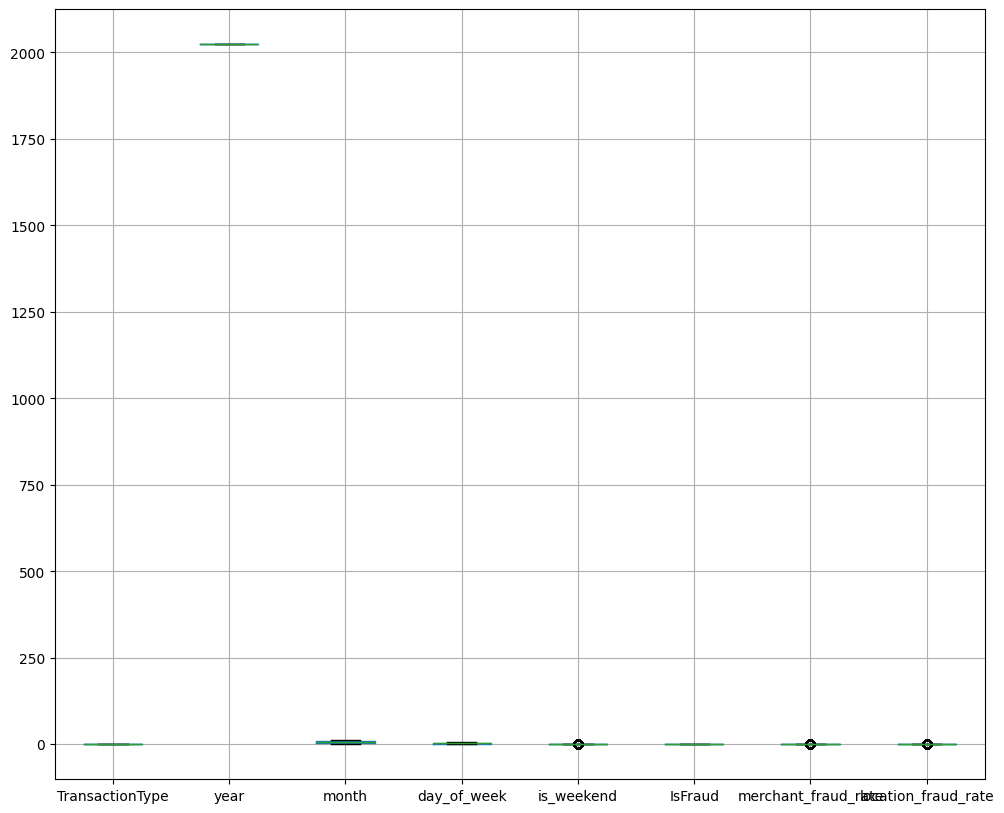

In [ ]:
plt.figure(figsize=(12,10))

df.boxplot()

In [ ]:
def remove_outliers_iqr(df, exclude_column):
  for col in df.columns:

    if col == exclude_column:
      continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
  return df

df_cleaned = remove_outliers_iqr(df, exclude_column='IsFraud')
df = df_cleaned

In [ ]:
df

,TransactionType,year,month,day_of_week,is_weekend,IsFraud,merchant_fraud_rate,location_fraud_rate
0,1,2024,4,2,0,0,0.525862,0.529159
1,1,2024,3,1,0,0,0.418367,0.505232
2,0,2024,1,0,0,0,0.625000,0.580559
4,0,2024,7,4,0,0,0.565421,0.544842
5,0,2024,8,4,0,0,0.478049,0.580559
...,...,...,...,...,...,...,...,...
197995,0,2024,3,1,0,1,0.407609,0.580559
197996,0,2023,7,2,0,1,0.579439,0.572160
197997,1,2023,9,2,0,1,0.595041,0.547551
197998,0,2024,1,1,0,1,0.477778,0.580559


## **data scaling**

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features = ['TransactionType', 'year', 'month', 'day_of_week', 'is_weekend', 'merchant_fraud_rate', 'location_fraud_rate']

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])

scaled_df = pd.DataFrame(scaled_data, columns=features)

## **train_test_split**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x = df[['TransactionType', 'year', 'month', 'day_of_week', 'is_weekend', 'merchant_fraud_rate', 'location_fraud_rate']]
y = df['IsFraud']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy: 0.2f}')

Baseline model accuracy:  0.67


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## **Kfold**

In [ ]:
from sklearn.model_selection import KFold

x = df.drop("IsFraud", axis=1)
y = df["IsFraud"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegression()


best_accuracy = 0
best_fold = -1

best_x_train = None
best_y_train = None
best_x_test = None
best_y_test = None
best_y_pred = None


for fold, (train_index, test_index) in enumerate(kf.split(x), 1):
  x_train, x_test = x.iloc[train_index], x.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  model.fit(x_train,y_train)

  y_pred = model.predict(x_test)
  acc = accuracy_score(y_test, y_pred)
  print(f"Fold {fold} Accuracy: {acc}")


  if acc > best_accuracy:
     best_accuracy = acc
     best_fold = fold
     best_x_train = x_train
     best_y_train = y_train
     best_x_test = x_test
     best_y_test = y_test
     best_y_pred = y_pred

print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 1 Accuracy: 0.6751504729148753


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2 Accuracy: 0.6676268271711092


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 3 Accuracy: 0.671238177128117


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 4 Accuracy: 0.6758674061653553
Fold 5 Accuracy: 0.6736317124553937

 Best Fold: 4 with Accuracy: 0.6758674061653553


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model = LogisticRegression()
model.fit(best_x_train, best_y_train)
model.score(best_x_test, best_y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.6758674061653553

## **decision tree algorithm**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(best_x_train, best_y_train)

best_y_pred = model.predict(best_x_test)

accuracy = accuracy_score(best_y_test, best_y_pred)

print(f"Baseline model accuracy: {accuracy: 0.2f}")

Baseline model accuracy:  0.71


## **support vector machine**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([('scaler', StandardScaler()),('model', LinearSVC(random_state=42, max_iter=5000))])

pipeline.fit(best_x_train, best_y_train)

y_pred = pipeline.predict(best_x_test)

print("Accuracy:", accuracy_score(best_y_test, best_y_pred))

Accuracy: 0.7094028118147814


## **Random forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(best_x_train, best_y_train)
best_y_pred = model.predict(best_x_test)

accuracy = accuracy_score(best_y_test, best_y_pred)

print(f"Baseline model accuracy: {accuracy: 0.2f}")

Baseline model accuracy:  0.72


In [ ]:
model = RandomForestClassifier(
    n_estimators=800,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

model.fit(best_x_train, best_y_train)
best_y_pred = model.predict(best_x_test)

accuracy = accuracy_score(best_y_test, best_y_pred)

print(f"Baseline model accuracy: {accuracy: 0.2f}")

Baseline model accuracy:  0.75


## **XGBoost Model**

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=3,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    random_state=42,
    eval_metric="auc"
)

model.fit(best_x_train, best_y_train)
best_y_pred = model.predict(best_x_test)

accuracy = accuracy_score(best_y_test, best_y_pred)

print(f"Baseline model accuracy: {accuracy: 0.2f}")

Baseline model accuracy:  0.75


## **DL**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.metrics import Accuracy

In [ ]:
model = Sequential([Dense(128, input_shape=(7,), activation='relu'),
                    Dense(64, activation='relu'),
                    Dense(32, activation='relu'),
                    Dense(1, activation='sigmoid')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'] )

In [ ]:
model.fit(best_x_train, best_y_train, epochs=20,batch_size=32)

Epoch 1/20
2908/2908 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6429 - loss: 0.6518
Epoch 2/20
2908/2908 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6402 - loss: 0.6534
Epoch 3/20
2908/2908 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6404 - loss: 0.6533
Epoch 4/20
2908/2908 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6405 - loss: 0.6532
Epoch 5/20
2908/2908 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6407 - loss: 0.6531
Epoch 6/20
2908/2908 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6407 - loss: 0.6532
Epoch 7/20
2908/2908 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6391 - loss: 0.6540
Epoch 8/20
2908/2908 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6410 - loss: 0.6530
Epoch 9/20
2908/2908 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6401 - loss: 0.6535
Epoch 10/20
2908/2908 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6380 - loss: 0.6547
Epoch 11/20
2908/2908 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6401 - loss: 0.6535
Epoch 12/20
2908/2908 ━━━━━━━━

In [ ]:
test_loss, test_acc = model.evaluate(best_x_test, best_y_test)

print(f'\nTest Accuracy: {test_acc}')

727/727 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2804 - loss: 0.8700

Test Accuracy: 0.643879771232605


In [ ]:
model = RandomForestClassifier(
    n_estimators=800,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

model.fit(best_x_train, best_y_train)
best_y_pred = model.predict(best_x_test)

accuracy = accuracy_score(best_y_test, best_y_pred)

print(f"Baseline model accuracy: {accuracy: 0.2f}")

Baseline model accuracy:  0.75


In [ ]:
import pickle
with open("creditcardfrauddetection_randomforest_model.pkl","wb") as file:
  pickle.dump(model,file)

In [ ]:
with open("/content/creditcardfrauddetection_randomforest_model.pkl","rb") as file:
  load_model=pickle.load(file)

In [ ]:
best_y_pred = load_model.predict(best_x_test)

accuracy = accuracy_score(best_y_test, best_y_pred)

print(f"Baseline model accuracy: {accuracy: 0.2f}")

Baseline model accuracy:  0.75


## **Conclusion**

This project focused on building an effective credit card fraud detection system using machine learning techniques. The dataset initially exhibited class imbalance, which could negatively impact model performance. To address this issue, SMOTE (Synthetic Minority Over-sampling Technique) was applied to balance the dataset and ensure fair learning across both fraud and non-fraud classes. Multiple machine learning algorithms were implemented and evaluated to identify the most suitable model for fraud prediction.

Among the models tested, Random Forest achieved the highest accuracy and demonstrated strong performance in detecting fraudulent transactions. The final optimized model was serialized and saved in pickle format for deployment and future use in real-time prediction systems. Overall, this project highlights the importance of handling class imbalance and model comparison in developing reliable fraud detection solutions.